#  Transfer Value Model Trainer (Colab Compatible)

This notebook retrains your offense, midfield, and defense models using your full modeling + evaluation pipeline. It also saves each Random Forest (raw) pipeline to a `.pkl` file for later use in your app.


In [ ]:
!pip install scikit-learn pandas matplotlib joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving all_leagues_defense.csv to all_leagues_defense.csv
Saving all_leagues_midfield.csv to all_leagues_midfield.csv
Saving all_leagues_offense.csv to all_leagues_offense.csv



📈 Features Selected (|correlation| > 0.3):
['Gls_Per_Minutes', 'PK', 'Gls', 'Ast', 'G+A', 'xG_Expected.x', 'xAG_Expected', 'Sh_Standard']

📈 Features Selected (|correlation| > 0.3):
['Ast', 'xAG', 'KP', 'PrgP', 'PrgC_Carries']

📈 Features Selected (|correlation| > 0.25):
['Unnamed: 0', 'Att 3rd_Tackles', 'Blocks_Blocks', 'Pass_Blocks']


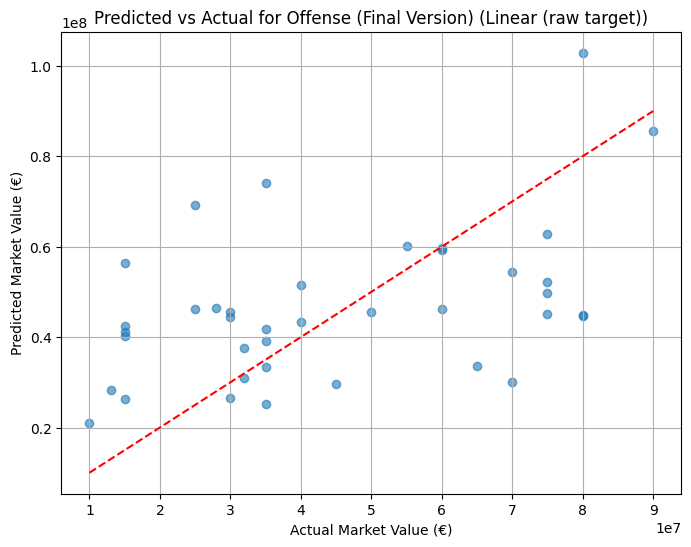

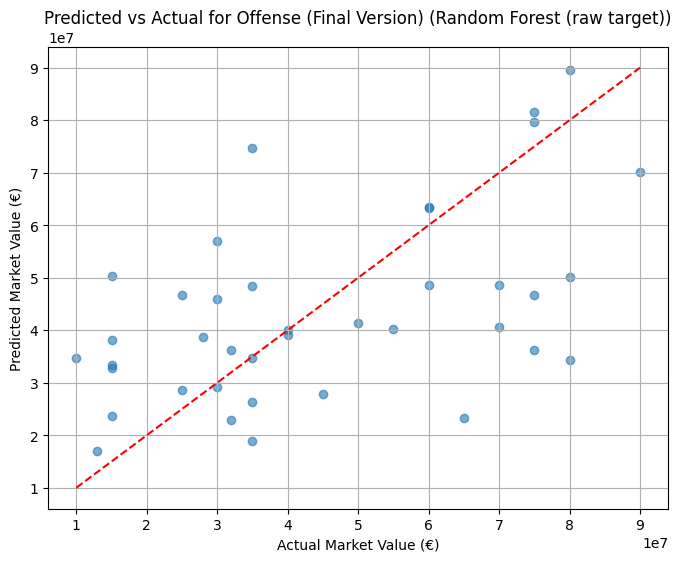

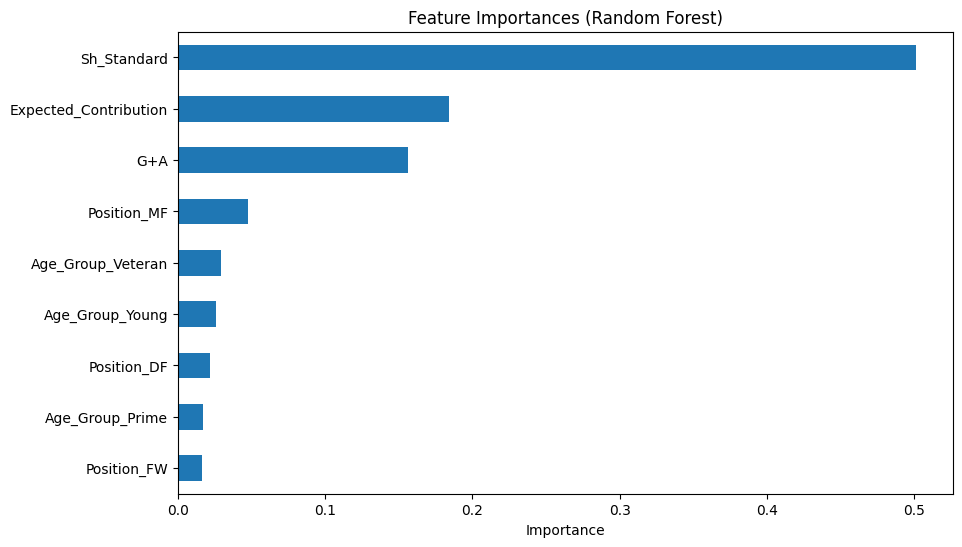


📊 Results for Offense (Final Version):
                     Model  R² Score         RMSE
       Linear (raw target)  0.154573 2.141236e+07
       Linear (log target) -0.081874 2.422227e+07
Random Forest (raw target)  0.218450 2.058757e+07
Random Forest (log target)  0.067701 2.248559e+07


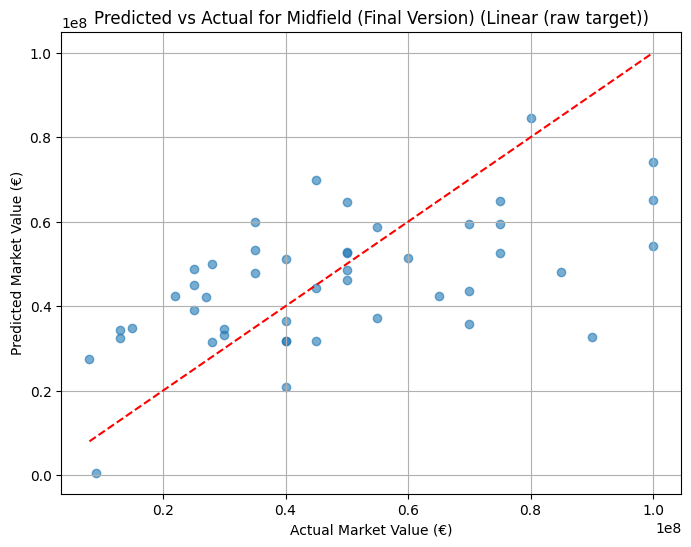

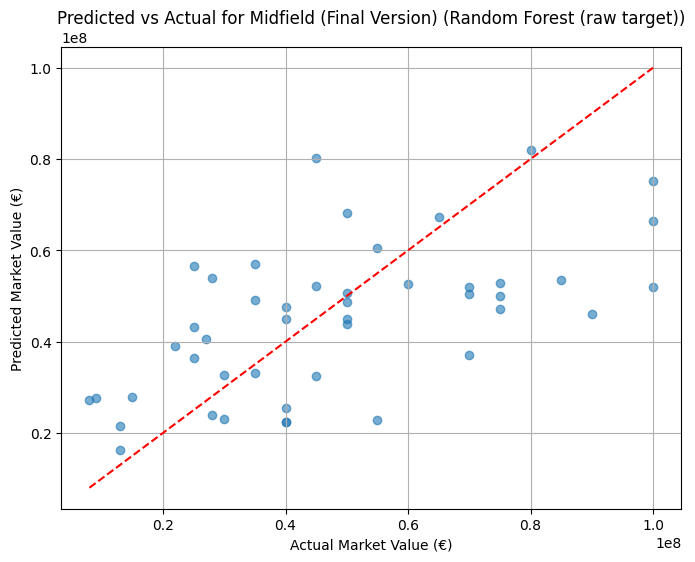

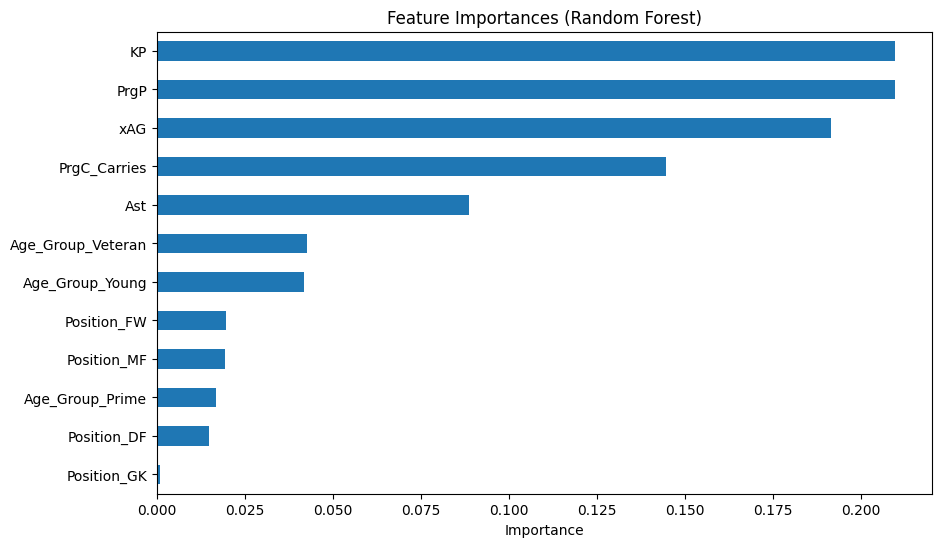


📊 Results for Midfield (Final Version):
                     Model  R² Score         RMSE
       Linear (raw target)  0.318682 2.040977e+07
       Linear (log target)  0.161976 2.263556e+07
Random Forest (raw target)  0.329149 2.025239e+07
Random Forest (log target)  0.132249 2.303354e+07


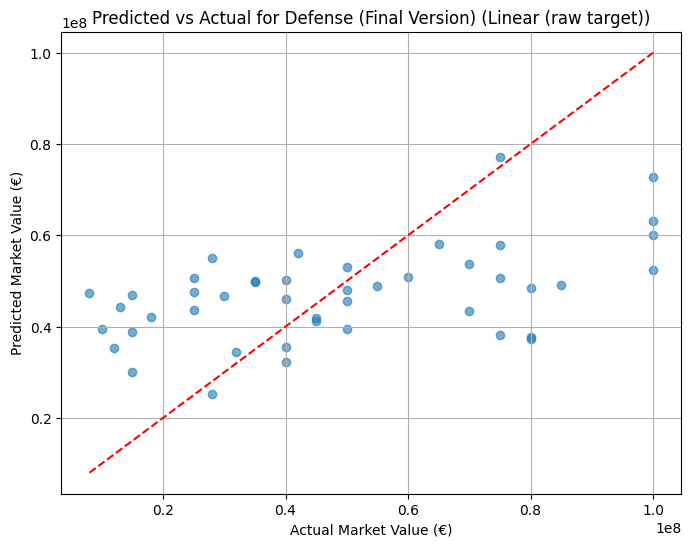

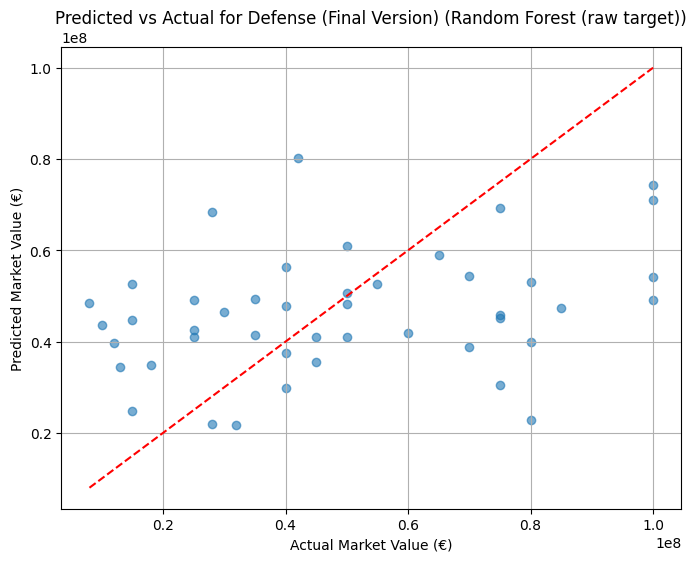

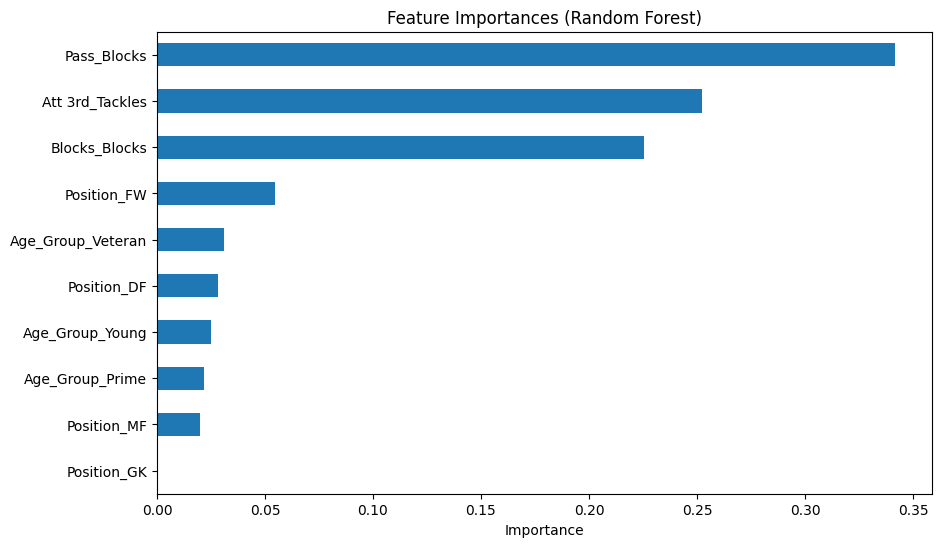


📊 Results for Defense (Final Version):
                     Model  R² Score         RMSE
       Linear (raw target)  0.236338 2.364282e+07
       Linear (log target)  0.152417 2.490806e+07
Random Forest (raw target)  0.062420 2.619708e+07
Random Forest (log target) -0.075741 2.806097e+07

✅ All models trained and pipelines saved.


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

df_offense = pd.read_csv("all_leagues_offense.csv")
df_midfield = pd.read_csv("all_leagues_midfield.csv")
df_defense = pd.read_csv("all_leagues_defense.csv")

def feature_selection_via_correlation(df, target_column="Value", threshold=0.2):
    num_df = df.select_dtypes(include=np.number)
    corr_matrix = num_df.corr()
    target_corr = corr_matrix[target_column].drop(labels=[target_column])
    selected_features = target_corr[abs(target_corr) > threshold].index.tolist()
    print(f"\n Features Selected (|correlation| > {threshold}):")
    print(selected_features)
    return selected_features

feature_selection_via_correlation(df_offense, "Value", 0.3)
feature_selection_via_correlation(df_midfield, "Value", 0.3)
feature_selection_via_correlation(df_defense, "Value", 0.25)

def bin_age(age):
    if pd.isnull(age):
        return np.nan
    elif age <= 22:
        return "Young"
    elif 23 <= age <= 29:
        return "Prime"
    else:
        return "Veteran"

def clean_columns(df):
    rename_map = {}
    if "Value.x" in df.columns: rename_map["Value.x"] = "Value"
    if "Position.x" in df.columns: rename_map["Position.x"] = "Position"
    if "Age.x.x" in df.columns: rename_map["Age.x.x"] = "Age"
    if "Age.x" in df.columns and "Age" not in df.columns: rename_map["Age.x"] = "Age"
    return df.rename(columns=rename_map)

def plot_predicted_vs_actual(pipeline, X_test, y_test, dataset_name, model_name):
    y_pred = pipeline.predict(X_test)
    if model_name.endswith("(log target)"):
        y_test = np.exp(y_test)
        y_pred = np.exp(y_pred)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Market Value (€)")
    plt.ylabel("Predicted Market Value (€)")
    plt.title(f"Predicted vs Actual for {dataset_name} ({model_name})")
    plt.grid(True)
    plt.show()

selected_feature_list = {
    "Offense (Final Version)": ['G+A', 'Expected_Contribution', 'Sh_Standard'],
    "Midfield (Final Version)": ['Ast', 'xAG', 'KP', 'PrgP', 'PrgC_Carries'],
    "Defense (Final Version)": ['Att 3rd_Tackles', 'Blocks_Blocks', 'Pass_Blocks']
}

def run_modeling_pipeline(df, dataset_name, target_column="Value"):
    df = clean_columns(df)
    df = df.drop(columns=[col for col in ["Unnamed: 0", "Squad", "Pos", "Player", "Team",
                                          "PlayerURL", "Season", "Comp", "Nation",
                                          "Season.x", "Comp.x", "Nation.x", "Team.x", "Player.x", "Apps.x"]
                if col in df.columns], errors='ignore')
    df = df.dropna(subset=[target_column])
    winsorization_cap = 100_000_000
    df[target_column] = np.where(df[target_column] > winsorization_cap, winsorization_cap, df[target_column])

    if dataset_name == "Offense (Final Version)":
        if {"xG_Expected.x", "xAG_Expected"}.issubset(df.columns):
            df["Expected_Contribution"] = df["xG_Expected.x"] + df["xAG_Expected"]

    df["Age_Group"] = df["Age"].apply(bin_age)
    df["LogValue"] = np.log(df[target_column])
    df_cleaned = df.dropna()

    selected_features = selected_feature_list[dataset_name]
    keep_features = selected_features + ["Position", "Age_Group"]

    features = df_cleaned[keep_features]
    target_raw = df_cleaned["Value"]
    target_log = df_cleaned["LogValue"]

    num_cols = features.select_dtypes(include=np.number).columns.tolist()
    cat_cols = features.select_dtypes(include='object').columns.tolist()

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    models = {
        "Linear (raw target)": (LinearRegression(), target_raw, False),
        "Linear (log target)": (LinearRegression(), target_log, True),
        "Random Forest (raw target)": (RandomForestRegressor(n_estimators=100, random_state=42), target_raw, False),
        "Random Forest (log target)": (RandomForestRegressor(n_estimators=100, random_state=42), target_log, True)
    }

    results = []
    for name, (model, target, is_log) in models.items():
        X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
        pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
        pipeline.fit(X_train, y_train)

        if name == "Random Forest (raw target)":
            if dataset_name == "Offense (Final Version)":
                joblib.dump(pipeline, "pipeline_offense.pkl")
            elif dataset_name == "Midfield (Final Version)":
                joblib.dump(pipeline, "pipeline_midfield.pkl")
            elif dataset_name == "Defense (Final Version)":
                joblib.dump(pipeline, "pipeline_defense.pkl")

        y_pred = pipeline.predict(X_test)
        y_test_eval = np.exp(y_test) if is_log else y_test
        y_pred_eval = np.exp(y_pred) if is_log else y_pred

        rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
        r2 = r2_score(y_test_eval, y_pred_eval)

        results.append((name, r2, rmse))

        if name == "Random Forest (raw target)":
            plot_predicted_vs_actual(pipeline, X_test, y_test, dataset_name, name)
            feature_names = pipeline.named_steps['preprocessor'].transformers_[0][2] + list(pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out())
            importances = pipeline.named_steps['model'].feature_importances_
            pd.Series(importances, index=feature_names).sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
            plt.title("Feature Importances (Random Forest)")
            plt.xlabel("Importance")
            plt.show()

        if name == "Linear (raw target)":
            plot_predicted_vs_actual(pipeline, X_test, y_test, dataset_name, name)

    results_df = pd.DataFrame(results, columns=["Model", "R² Score", "RMSE"])
    print(f"\n Results for {dataset_name}:")
    print(results_df.to_string(index=False))

run_modeling_pipeline(df_offense, "Offense (Final Version)")
run_modeling_pipeline(df_midfield, "Midfield (Final Version)")
run_modeling_pipeline(df_defense, "Defense (Final Version)")


In [ ]:
from google.colab import files
files.download("pipeline_offense.pkl")
files.download("pipeline_midfield.pkl")
files.download("pipeline_defense.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>